In [1]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import pandas as pd
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from statsmodels.formula.api import ols
from statsmodels.stats.diagnostic import het_breuschpagan


In [2]:
df = pd.read_csv('flats R.csv', sep=';')
df = df.rename(columns={'Тип': 'Type','Арендная плаиа': 'Rent', 'Этаж': 'Floor', 'Общее количество этажей в доме': 'Total_Floors', 'Площадь': 'Area', 'Мебель': 'Furniture'})
print(df.head())
df['Area'] = df['Area'].str.replace(',', '.').astype(float)

     Type  Rent  Floor  Total_Floors  Area Furniture
0  студия  8500      1             5    15       нет
1  студия  9000      1             5    14       нет
2  студия  9500      8             9    15      есть
3  студия  8000      1             5  12,2      есть
4  студия  9000      2             5    18      есть


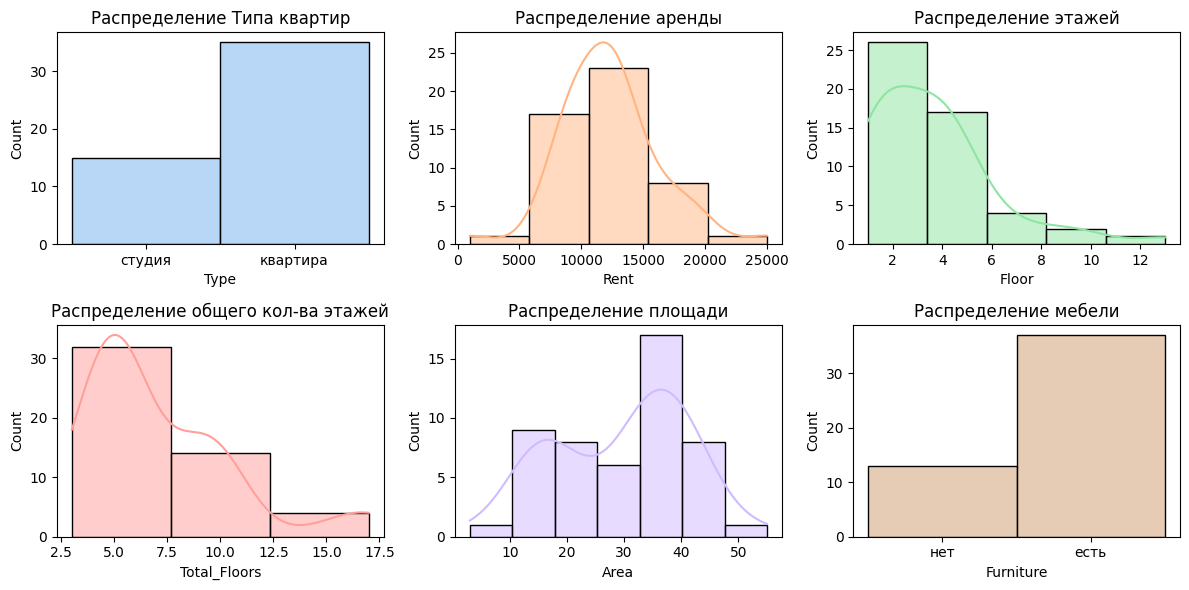

In [3]:
fig, ax = plt.subplots(2, 3, figsize=(12, 6))

colors = sns.color_palette("pastel")

sns.histplot(data = df['Type'], color=colors[0], ax=ax[0, 0])
ax[0, 0].set_title("Распределение Типа квартир")

sns.histplot(data = df['Rent'], color=colors[1], bins = 5, kde=True, ax=ax[0, 1])
ax[0, 1].set_title("Распределение аренды")

sns.histplot(data = df['Floor'], color=colors[2], bins = 5, kde=True, ax=ax[0, 2])
ax[0, 2].set_title("Распределение этажей")

sns.histplot(data = df['Total_Floors'], color=colors[3], bins = 3, kde=True, ax=ax[1, 0])
ax[1, 0].set_title("Распределение общего кол-ва этажей")

sns.histplot(data = df['Area'], color=colors[4], kde=True, ax=ax[1, 1])
ax[1, 1].set_title("Распределение площади")

sns.histplot(data = df['Furniture'], color=colors[5], ax=ax[1, 2])
ax[1, 2].set_title("Распределение мебели")

plt.tight_layout()
plt.show()

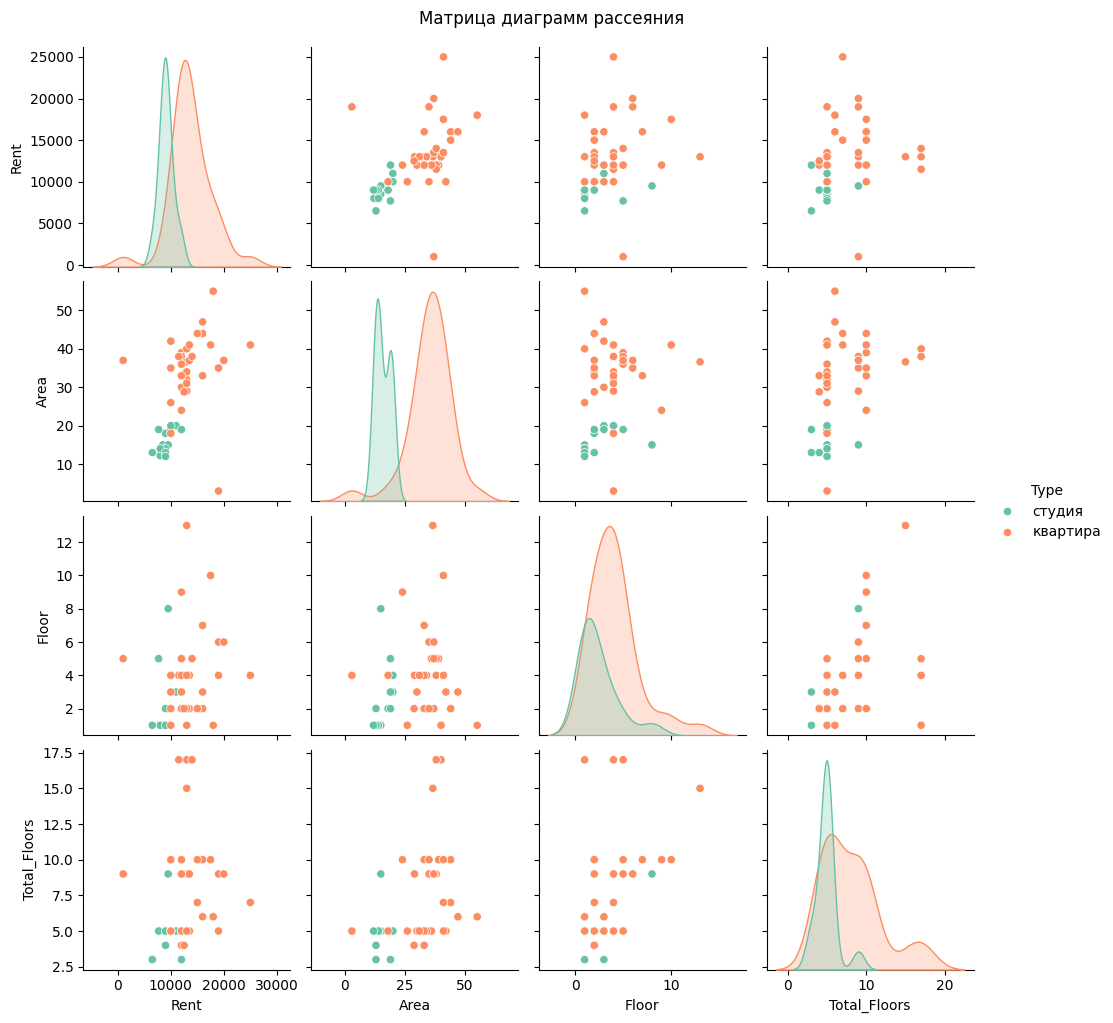

In [4]:
sns.pairplot(df, vars=['Rent', 'Area', 'Floor', 'Total_Floors'],hue='Type', diag_kind='kde', palette='Set2')
plt.suptitle('Матрица диаграмм рассеяния', y=1.02)
plt.show()

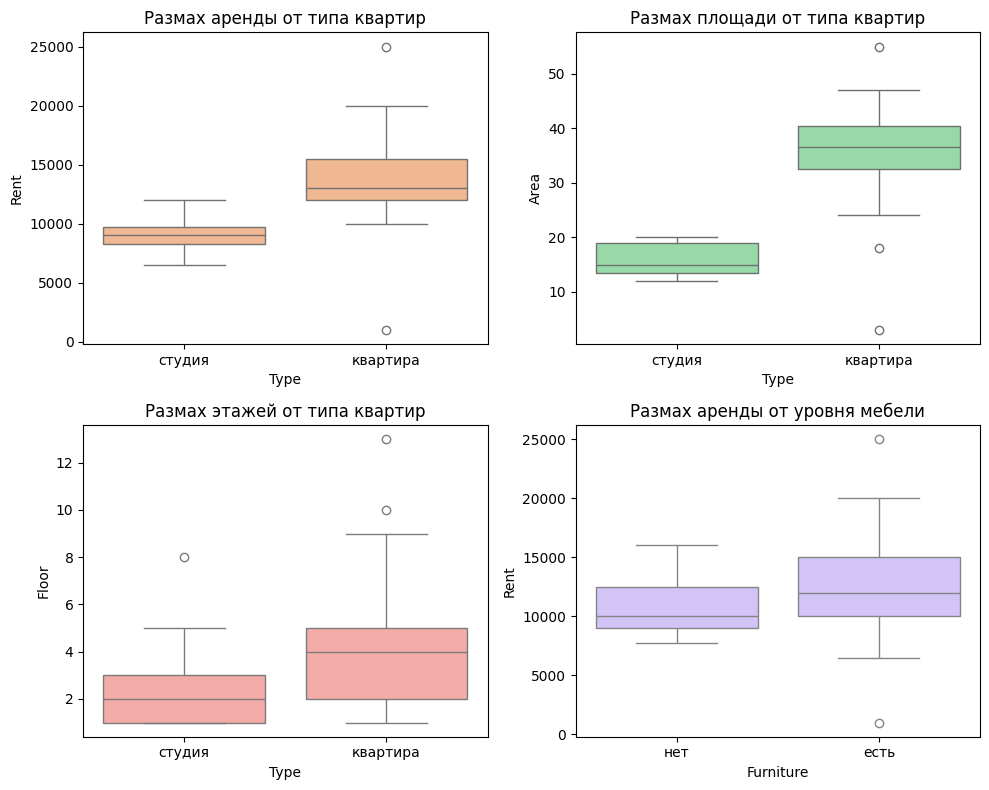

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8))

colors = sns.color_palette("pastel")

sns.boxplot(x = 'Type', y = 'Rent', data = df, color=colors[1], ax=ax[0, 0])
ax[0, 0].set_title("Размах аренды от типа квартир")

sns.boxplot(x = 'Type', y = 'Area', data = df, color=colors[2], ax=ax[0, 1])
ax[0, 1].set_title("Размах площади от типа квартир")

sns.boxplot(x = 'Type', y = 'Floor', data = df, color=colors[3], ax=ax[1, 0])
ax[1, 0].set_title("Размах этажей от типа квартир")

sns.boxplot(x = 'Furniture', y = 'Rent', data = df, color=colors[4], ax=ax[1, 1])
ax[1, 1].set_title("Размах аренды от уровня мебели")

plt.tight_layout()
plt.show()

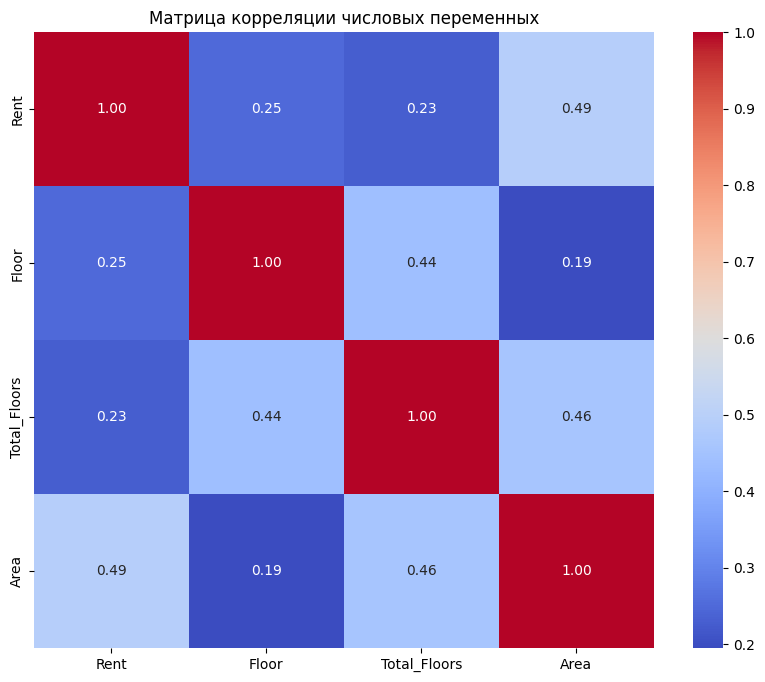

In [6]:
corr = df[['Rent', 'Floor', 'Total_Floors', 'Area']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Матрица корреляции числовых переменных')
plt.show()

In [7]:
print("УДАЛЕНИЕ ВЫБРОСОВ")
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] >= lower) & (data[column] <= upper)]

df_clean = df.copy()
for col in ['Rent', 'Area', 'Floor', 'Total_Floors']:
    before = len(df_clean)
    df_clean = remove_outliers_iqr(df_clean, col)
    after = len(df_clean)
    print(f"Удалено выбросов по '{col}': {before - after}")

print(f"Размер данных после удаления выбросов: {df_clean.shape}")
df = df_clean.copy()

УДАЛЕНИЕ ВЫБРОСОВ
Удалено выбросов по 'Rent': 5
Удалено выбросов по 'Area': 0
Удалено выбросов по 'Floor': 4
Удалено выбросов по 'Total_Floors': 3
Размер данных после удаления выбросов: (38, 6)


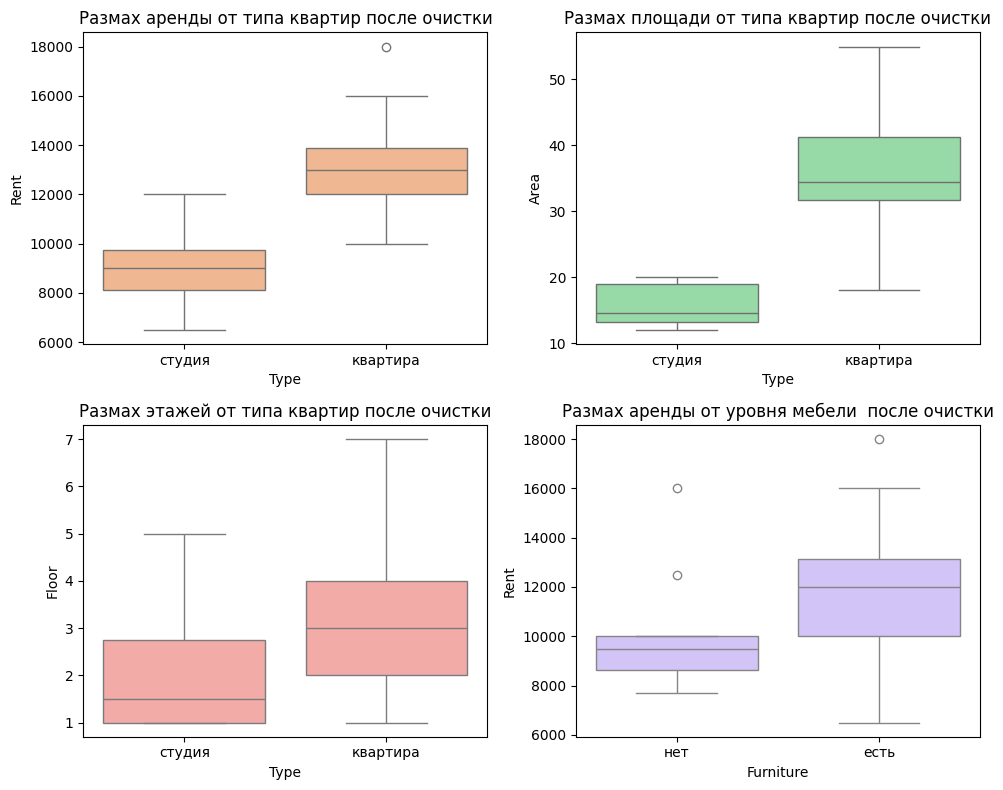

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8))

colors = sns.color_palette("pastel")

sns.boxplot(x = 'Type', y = 'Rent', data = df, color=colors[1], ax=ax[0, 0])
ax[0, 0].set_title("Размах аренды от типа квартир после очистки")

sns.boxplot(x = 'Type', y = 'Area', data = df, color=colors[2], ax=ax[0, 1])
ax[0, 1].set_title("Размах площади от типа квартир после очистки")

sns.boxplot(x = 'Type', y = 'Floor', data = df, color=colors[3], ax=ax[1, 0])
ax[1, 0].set_title("Размах этажей от типа квартир после очистки")

sns.boxplot(x = 'Furniture', y = 'Rent', data = df, color=colors[4], ax=ax[1, 1])
ax[1, 1].set_title("Размах аренды от уровня мебели  после очистки")

plt.tight_layout()
plt.show()

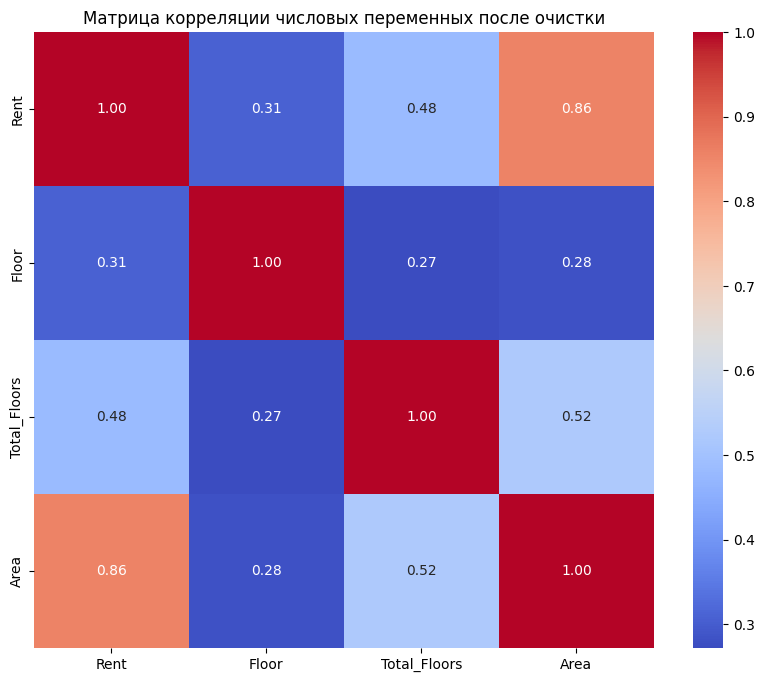

In [9]:
corr = df[['Rent', 'Floor', 'Total_Floors', 'Area']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Матрица корреляции числовых переменных после очистки')
plt.show()

In [10]:
df['Type'] = df['Type'].astype('category')
df['Furniture'] = df['Furniture'].astype('category')

model_all = ols('Rent ~ Area + Floor + Total_Floors + C(Type) + C(Furniture)', data=df).fit()
print("ANOVA")
print(sm.stats.anova_lm(model_all, typ=2))

ANOVA
                    sum_sq    df          F    PR(>F)
C(Type)       5.931690e+02   1.0   0.000306  0.986147
C(Furniture)  8.062068e+06   1.0   4.162292  0.049658
Area          4.275074e+07   1.0  22.071392  0.000048
Floor         1.663057e+03   1.0   0.000859  0.976806
Total_Floors  9.949766e+05   1.0   0.513687  0.478746
Residual      6.198176e+07  32.0        NaN       NaN


Сильнейшее влияние у Area < 0.05. Затем идет Furniture, но она находится на границе критической значимой. Остальные никак не влияют. Сумма квадратов остатков больше, чем сумма квадратов фактора площади, то есть в данных очень много необъясненной случайной вариации.

Text(0.5, 1.0, 'Зависимость Rent от Area')

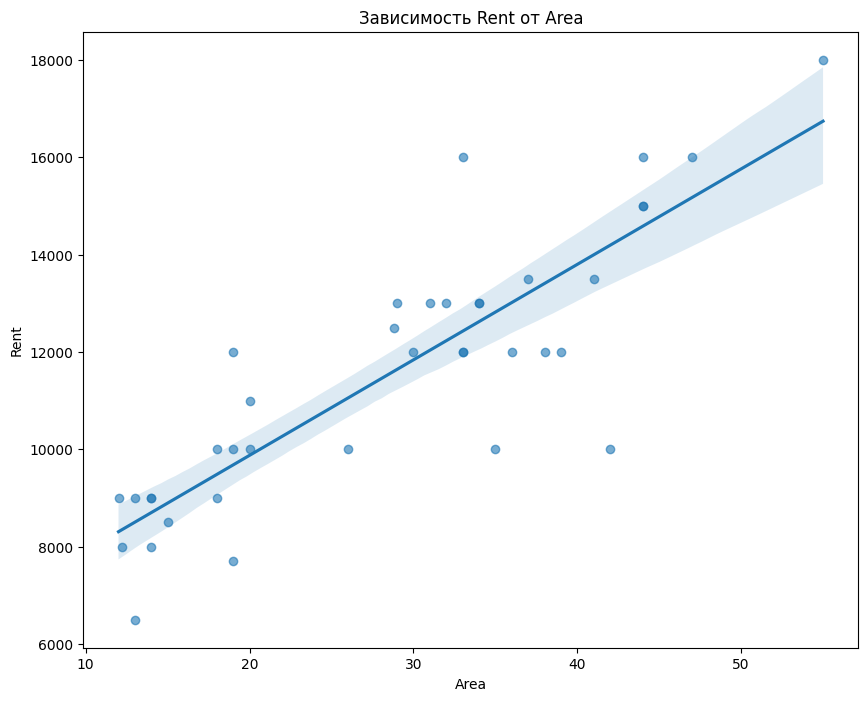

In [11]:
plt.figure(figsize=(10, 8))
sns.regplot(x='Area', y='Rent', data=df, scatter_kws={'alpha':0.6})

plt.title('Зависимость Rent от Area')

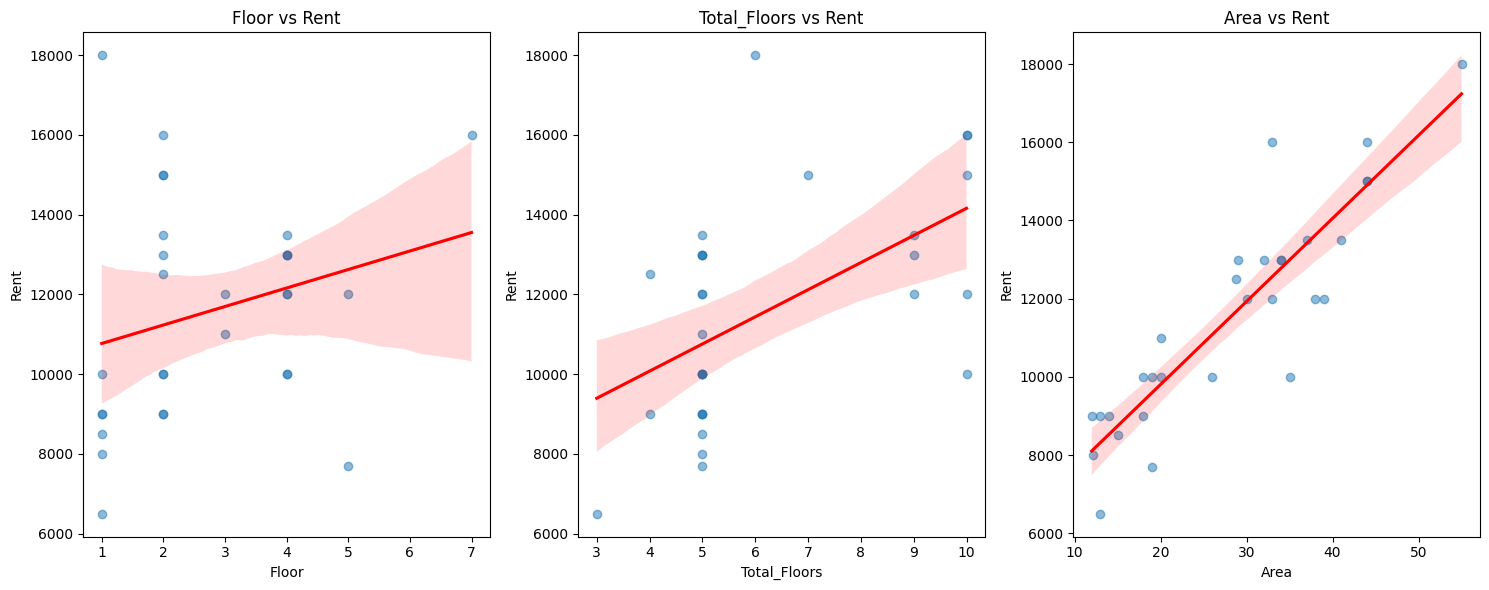

In [12]:
X = df.drop(['Rent'], axis=1)
y = df['Rent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

results = []
for col in numeric_features:
    
    # Берём только один признак (нужно привести к 2D-массиву)
    X_train_1d = X_train[[col]]
    X_test_1d = X_test[[col]]
    
    model = LinearRegression()
    model.fit(X_train_1d, y_train)
    
    r2_train = model.score(X_train_1d, y_train)
    r2_test = model.score(X_test_1d, y_test)
    
    results.append({
        'Признак': col,
        'Коэффициент': model.coef_[0],
        'Свободный член': model.intercept_,
        'R2 train': r2_train,
        'R2 test': r2_test
    })

pd.DataFrame(results).sort_values('R2 test', ascending=False)

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.regplot(x=X_train[col], y=y_train, ax=axes[i],
                line_kws={'color': 'red'}, scatter_kws={'alpha': 0.5})
    axes[i].set_title(f'{col} vs Rent')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Rent')


plt.tight_layout()
plt.show()

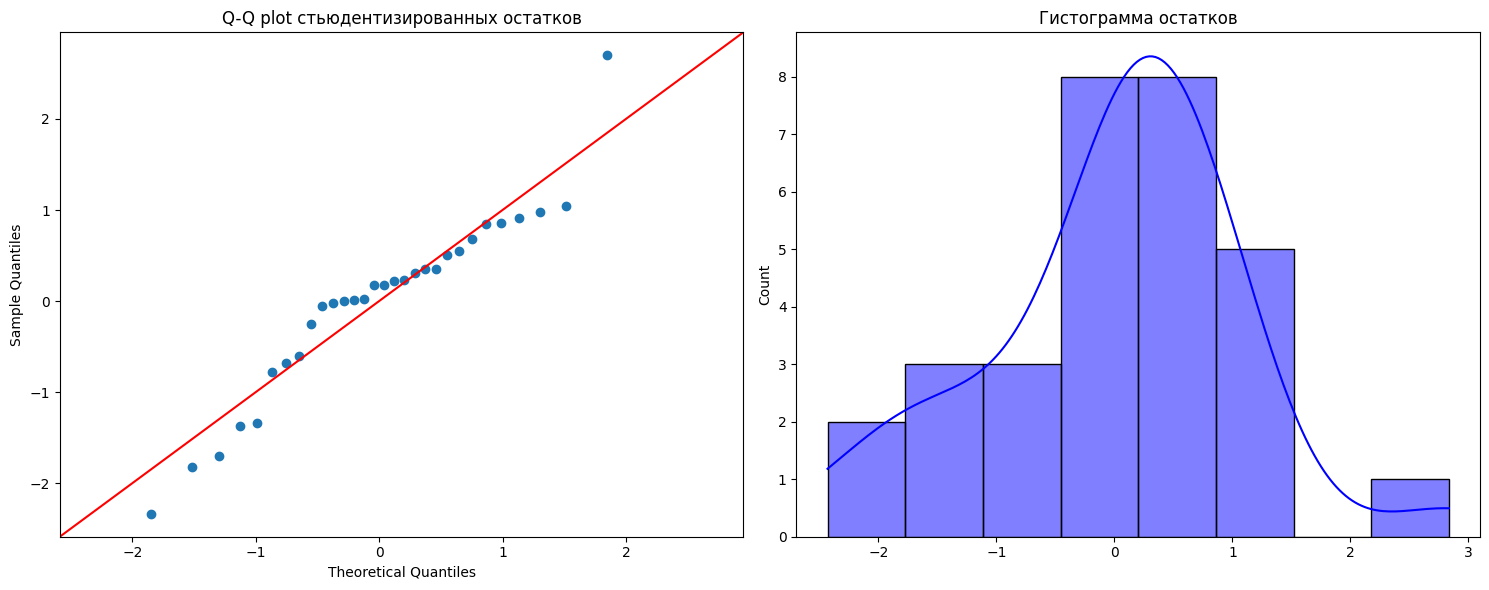

Шапиро-Уилка p-value: 0.0950
Нормальность остатков не отвергается.


In [13]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

# Обучаем препроцессор
preprocessor.fit(X_train)

# Трансформируем и добавляем константу
X_train_sm = preprocessor.transform(X_train)
X_train_sm = sm.add_constant(X_train_sm)

# Модель statsmodels
ols_model = sm.OLS(y_train, X_train_sm).fit()
influence = ols_model.get_influence()
standardized_residuals = influence.resid_studentized_internal

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
axes = axes.flatten()

sm.qqplot(standardized_residuals, dist=stats.norm, ax =axes[0], line='45', fit=True)
axes[0].set_title("Q-Q plot стьюдентизированных остатков")
sns.histplot(standardized_residuals,kde=True, ax=axes[1], color='blue')
axes[1].set_title('Гистограмма остатков')
plt.tight_layout()
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(standardized_residuals)

print(f"Шапиро-Уилка p-value: {shapiro_p:.4f}")

if shapiro_p > 0.05:
    print("Нормальность остатков не отвергается.")
else:
    print("Остатки статистически значимо отличаются от нормальных — смотрим на Q-Q plot.")


Обучаем модель обычного метода наименьших квадратов (линейную регрессию).

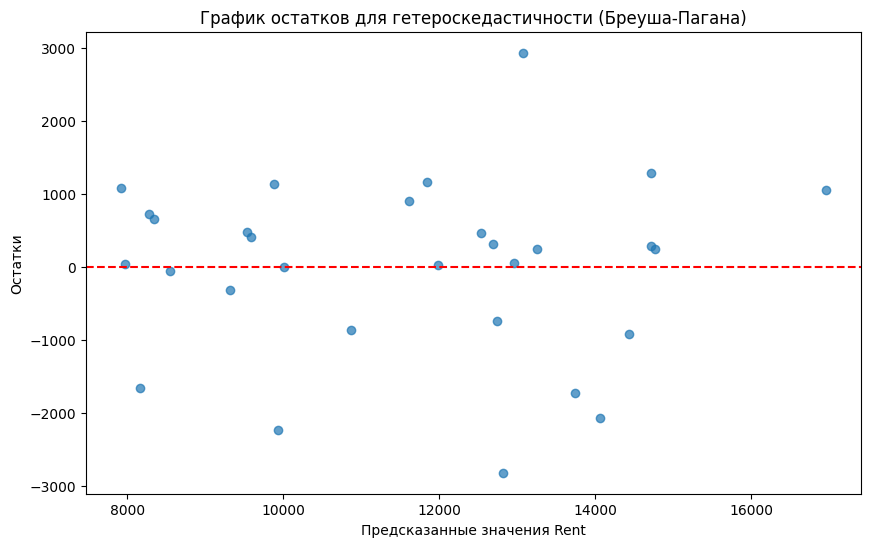

In [28]:
residuals = ols_model.resid
fitted = ols_model.fittedvalues

plt.figure(figsize=(10, 6))
plt.scatter(fitted, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Предсказанные значения Rent')
plt.ylabel('Остатки')
plt.title('График остатков для гетероскедастичности (Бреуша-Пагана)')
plt.show()

In [15]:
bp_test = het_breuschpagan(ols_model.resid, ols_model.model.exog)
labels = ['LM-статистика', 'p-value', 'f-статистика', 'f-p-value']
print("Breusch-Pagan test:")
for l, val in zip(labels, bp_test):
    print(f"{l}: {val:.6f}")

Breusch-Pagan test:
LM-статистика: 12.360120
p-value: 0.006246
f-статистика: 6.072663
f-p-value: 0.002829


p-value (0.0062) и f-p-value (0.0028) намного меньше критического уровня \(0.05\). в данных присутствует статистически значимая гетероскедастичность.

 Устранение гетероскедастичности для модели Rent - Area

Модель Rent_per_sqm - Area (деление на Area)
                            OLS Regression Results                            
Dep. Variable:           Rent_per_sqm   R-squared:                       0.752
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     109.1
Date:                Sat, 23 May 2026   Prob (F-statistic):           1.93e-12
Time:                        09:19:12   Log-Likelihood:                -211.19
No. Observations:                  38   AIC:                             426.4
Df Residuals:                      36   BIC:                             429.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

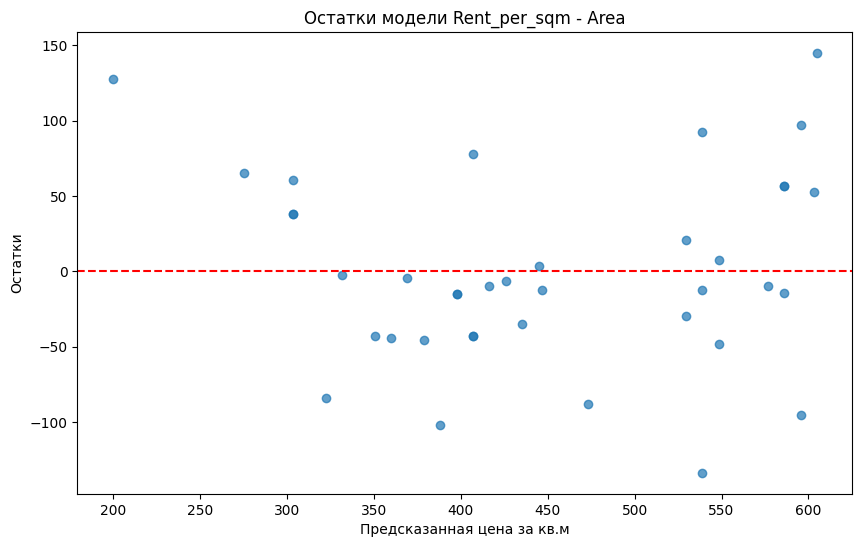

In [16]:
print(" Устранение гетероскедастичности для модели Rent - Area")

df['Rent_per_sqm'] = df['Rent'] / df['Area']

X_area = sm.add_constant(df['Area'])
y_psqm = df['Rent_per_sqm']
model_psqm = sm.OLS(y_psqm, X_area).fit()
print("\nМодель Rent_per_sqm - Area (деление на Area)")
print(model_psqm.summary())

resid_psqm = model_psqm.resid
bp_psqm = het_breuschpagan(resid_psqm, model_psqm.model.exog)
print("Тест Бреуша-Пагана после деления на Area:")
print(f"LM p-value: {bp_psqm[1]:.4f}")
    
plt.figure(figsize=(10,6))
plt.scatter(model_psqm.fittedvalues, resid_psqm, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Предсказанная цена за кв.м')
plt.ylabel('Остатки')
plt.title('Остатки модели Rent_per_sqm - Area')
plt.show()

Prob(Omnibus) = 0.796 и Prob(JB) = 0.801 Оба значения намного больше 0.05. Площадь объясняет 75.2% дисперсии стоимости квадратного метра


Модель Log(Rent) - Area (логарифмирование Y)
                            OLS Regression Results                            
Dep. Variable:               Log_Rent   R-squared:                       0.722
Model:                            OLS   Adj. R-squared:                  0.715
Method:                 Least Squares   F-statistic:                     93.63
Date:                Sat, 23 May 2026   Prob (F-statistic):           1.49e-11
Time:                        09:19:12   Log-Likelihood:                 25.821
No. Observations:                  38   AIC:                            -47.64
Df Residuals:                      36   BIC:                            -44.37
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const 

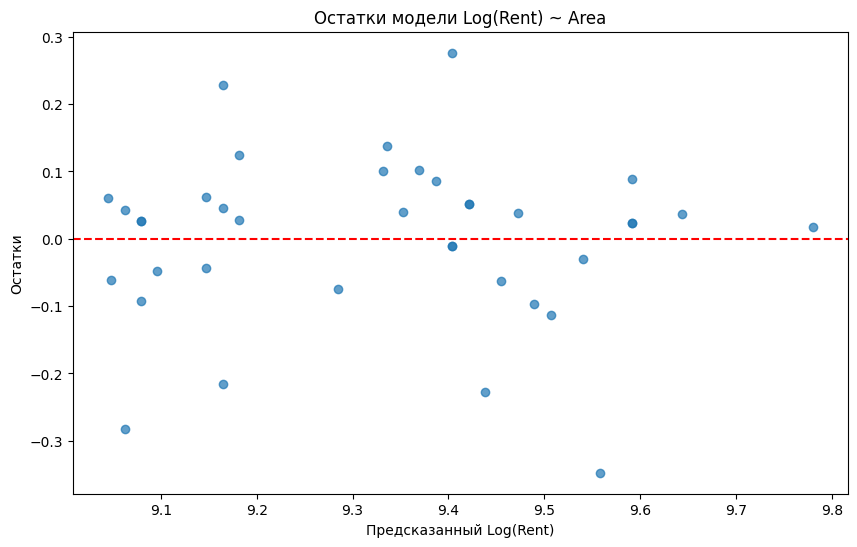

In [17]:
df['Log_Rent'] = np.log(df['Rent'])
y_log = df['Log_Rent']
model_log_area = sm.OLS(y_log, X_area).fit()
print("\nМодель Log(Rent) - Area (логарифмирование Y)")
print(model_log_area.summary())

resid_log = model_log_area.resid
bp_log = het_breuschpagan(resid_log, model_log_area.model.exog)
print("Тест Бреуша-Пагана после логарифмирования Rent:")
print(f"LM p-value: {bp_log[1]:.4f}")

plt.figure(figsize=(10,6))
plt.scatter(model_log_area.fittedvalues, resid_log, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Предсказанный Log(Rent)')
plt.ylabel('Остатки')
plt.title('Остатки модели Log(Rent) ~ Area')
plt.show()

In [18]:
print(" Новая парная модель Rent - Floor")
X_floor = sm.add_constant(df['Floor'])
y = df['Rent']
model_floor = sm.OLS(y, X_floor).fit()
print(model_floor.summary())

 Новая парная модель Rent - Floor
                            OLS Regression Results                            
Dep. Variable:                   Rent   R-squared:                       0.095
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     3.783
Date:                Sat, 23 May 2026   Prob (F-statistic):             0.0596
Time:                        09:19:12   Log-Likelihood:                -351.58
No. Observations:                  38   AIC:                             707.2
Df Residuals:                      36   BIC:                             710.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.003e

Проверка остатков модели Rent - Floor на нормальность


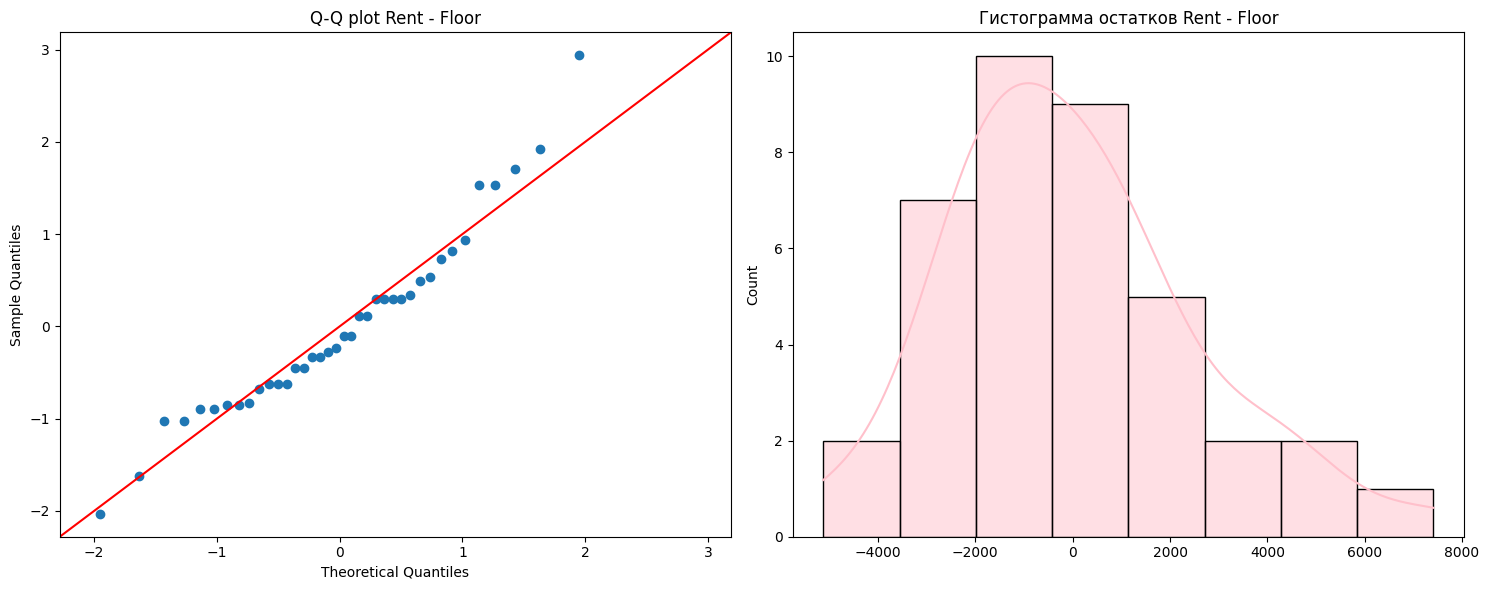

Шапиро-Уилка p-value: 0.1514


In [19]:
print("Проверка остатков модели Rent - Floor на нормальность")
residuals_floor = model_floor.resid

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
axes = axes.flatten()

sm.qqplot(residuals_floor, dist=stats.norm, ax =axes[0], line='45', fit=True)
axes[0].set_title("Q-Q plot Rent - Floor")
sns.histplot(residuals_floor,kde=True, ax=axes[1], color='Pink')
axes[1].set_title('Гистограмма остатков Rent - Floor')
plt.tight_layout()
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(residuals_floor)

print(f"Шапиро-Уилка p-value: {shapiro_p:.4f}")


Ошибки распределены нормально. Модели можно полностью доверять.

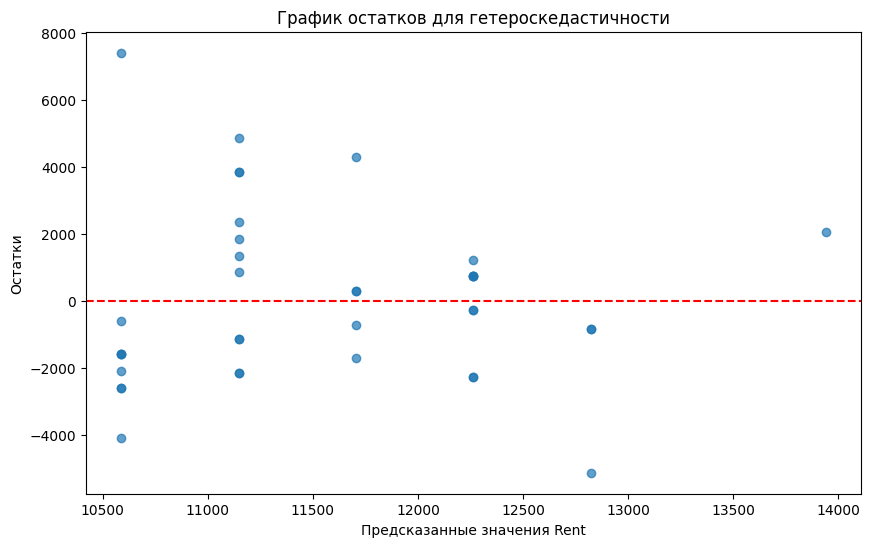

LM statistic: 1.6822
LM p-value: 0.1946
F-statistic: 1.6675
F p-value: 0.2048


In [20]:
fitted_floor = model_floor.fittedvalues

plt.figure(figsize=(10, 6))
plt.scatter(fitted_floor, residuals_floor, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Предсказанные значения Rent')
plt.ylabel('Остатки')
plt.title('График остатков для гетероскедастичности')
plt.show()


bp_test_floor = het_breuschpagan(residuals_floor, model_floor.model.exog)
bp_results_floor = dict(zip(['LM statistic', 'LM p-value', 'F-statistic', 'F p-value'], bp_test_floor))
for key, value in bp_results_floor.items():
    print(f"{key}: {value:.4f}")

 данных отсутствует статистически значимая гетероскедастичность.

 Диаграмма рассеяния  для Rent - Floor


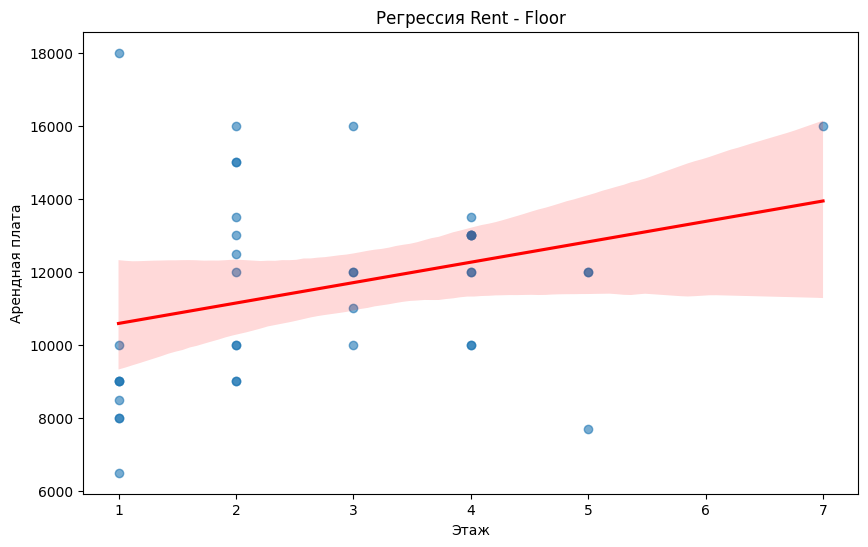

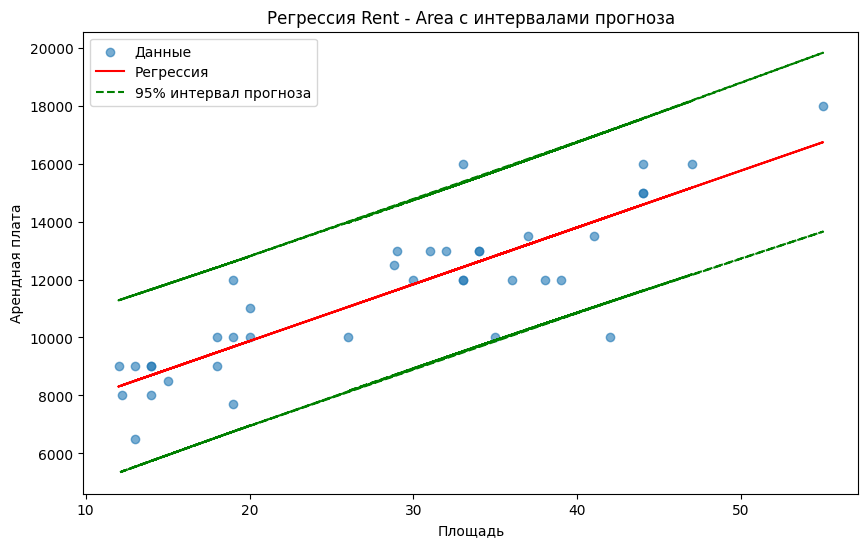

In [21]:
print(" Диаграмма рассеяния  для Rent - Floor")
plt.figure(figsize=(10, 6))
sns.regplot(x='Floor', y='Rent', data=df, ci=95, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Регрессия Rent - Floor')
plt.xlabel('Этаж')
plt.ylabel('Арендная плата')
plt.show()

from statsmodels.sandbox.regression.predstd import wls_prediction_std

X_area = sm.add_constant(df['Area'])
model_area = sm.OLS(y, X_area).fit()  
prstd, iv_l, iv_u = wls_prediction_std(model_area)
plt.figure(figsize=(10, 6))
plt.scatter(df['Area'], y, alpha=0.6, label='Данные')
plt.plot(df['Area'], model_area.fittedvalues, 'r-', label='Регрессия')
plt.plot(df['Area'], iv_l, 'g--', label='95% интервал прогноза')
plt.plot(df['Area'], iv_u, 'g--')
plt.xlabel('Площадь')
plt.ylabel('Арендная плата')
plt.title('Регрессия Rent - Area с интервалами прогноза')
plt.legend()
plt.show()

In [23]:
print(" Множественная регрессия )")
df_dummies = pd.get_dummies(df, columns=['Type', 'Furniture'], drop_first=True, dtype=int)

base_numeric = ['Area', 'Floor', 'Total_Floors']
possible_dummies = ['Type_квартира', 'Furniture_есть']
actual_dummies = [col for col in possible_dummies if col in df_dummies.columns]
predictor_cols = base_numeric + actual_dummies

X_multi = df_dummies[predictor_cols]
X_multi = sm.add_constant(X_multi)
y = df['Rent']
model_multi = sm.OLS(y, X_multi).fit()
print(model_multi.summary())

 Множественная регрессия )
                            OLS Regression Results                            
Dep. Variable:                   Rent   R-squared:                       0.738
Model:                            OLS   Adj. R-squared:                  0.715
Method:                 Least Squares   F-statistic:                     31.89
Date:                Sat, 23 May 2026   Prob (F-statistic):           5.39e-10
Time:                        09:19:32   Log-Likelihood:                -328.04
No. Observations:                  38   AIC:                             664.1
Df Residuals:                      34   BIC:                             670.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         5588.47

In [24]:
print("Удаление незначимых факторов")
pvalues = model_multi.pvalues
significant_vars = pvalues[pvalues < 0.05].index.tolist()
if 'const' not in significant_vars:
    significant_vars = ['const'] + significant_vars
else:
    significant_vars.remove('const')
    significant_vars = ['const'] + significant_vars

print("Значимые переменные (p<0.05):", significant_vars)

X_refined = X_multi[significant_vars]
model_refined = sm.OLS(y, X_refined).fit()
print(model_refined.summary())

Удаление незначимых факторов
Значимые переменные (p<0.05): ['const', 'Area']
                            OLS Regression Results                            
Dep. Variable:                   Rent   R-squared:                       0.732
Model:                            OLS   Adj. R-squared:                  0.725
Method:                 Least Squares   F-statistic:                     98.32
Date:                Sat, 23 May 2026   Prob (F-statistic):           7.79e-12
Time:                        09:20:08   Log-Likelihood:                -328.46
No. Observations:                  38   AIC:                             660.9
Df Residuals:                      36   BIC:                             664.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

In [25]:
print(" Прогноз арендной платы")
my_apartment ={
    'Area': 25.0,
    'Floor': 3,
    'TotalFloors': 5,
    'Type': 'студия',
    'Furniture': 'есть'
}
my_df = pd.DataFrame([my_apartment])
my_df_dummies = pd.get_dummies(my_df, columns=['Type', 'Furniture'], drop_first=True, dtype=int)

for col in X_refined.columns:
    if col not in my_df_dummies.columns and col != 'const':
        my_df_dummies[col] = 0

pred_cols = [c for c in X_refined.columns if c != 'const']
my_X = my_df_dummies[pred_cols]
my_X = sm.add_constant(my_X, has_constant='add')  

predicted_rent = model_refined.predict(my_X)[0]
print(f"Прогнозируемая арендная плата: {predicted_rent:.2f}")


 Прогноз арендной платы
Прогнозируемая арендная плата: 10856.22


 Анализ остатков уточнённой модели


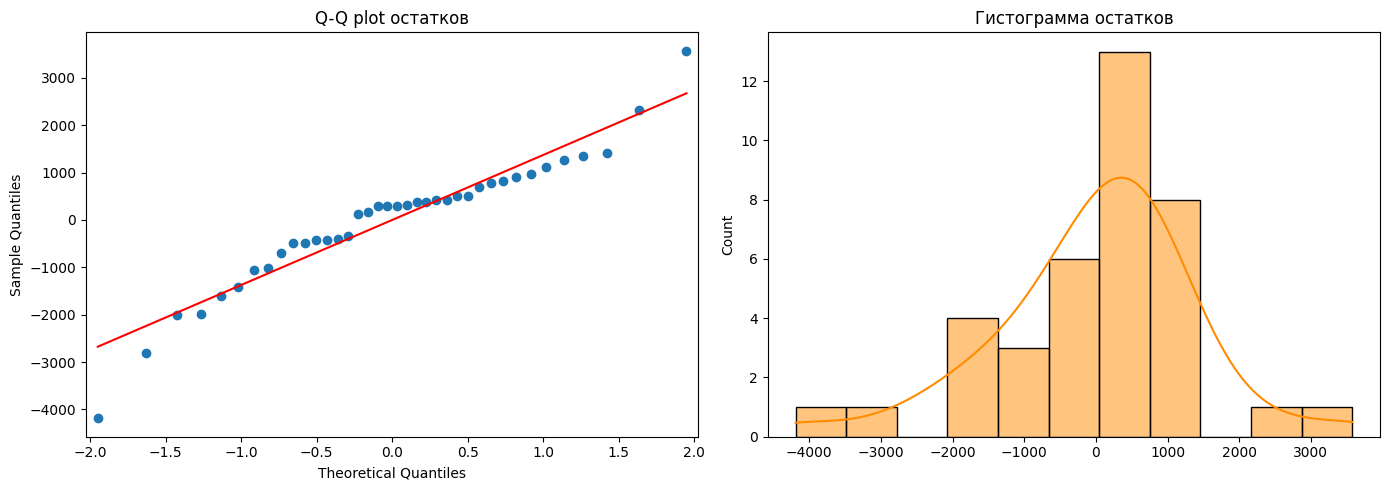

Тест Шапиро-Уилка: p-value = 0.0793


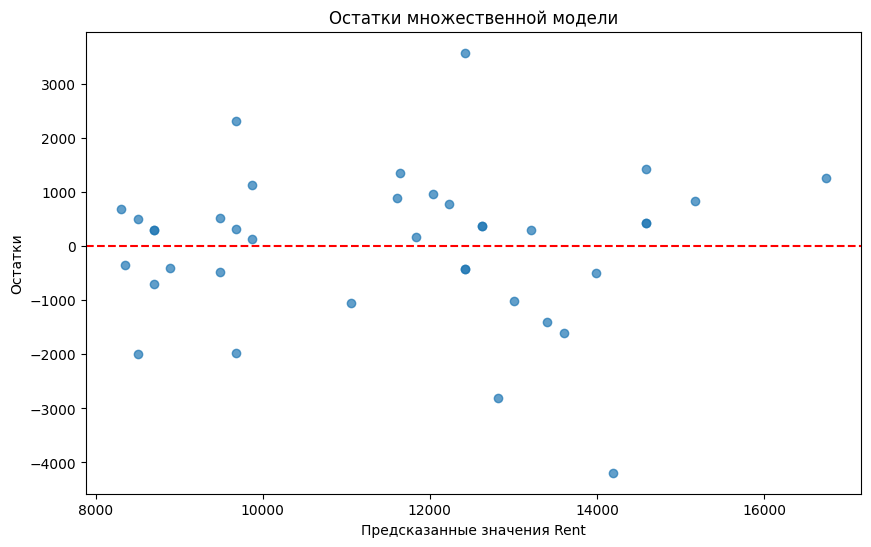

In [26]:
print(" Анализ остатков уточнённой модели")
residuals_multi = model_refined.resid
fitted_multi = model_refined.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sm.qqplot(residuals_multi, line='s', ax=axes[0])
axes[0].set_title('Q-Q plot остатков')
sns.histplot(residuals_multi, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Гистограмма остатков')
plt.tight_layout()
plt.show()

shapiro_stat_m, shapiro_p_m = stats.shapiro(residuals_multi)
print(f"Тест Шапиро-Уилка: p-value = {shapiro_p_m:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(fitted_multi, residuals_multi, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Предсказанные значения Rent')
plt.ylabel('Остатки')
plt.title('Остатки множественной модели')
plt.show()

Устранение гетероскедастичности логарифмированием
                            OLS Regression Results                            
Dep. Variable:               Log_Rent   R-squared:                       0.722
Model:                            OLS   Adj. R-squared:                  0.715
Method:                 Least Squares   F-statistic:                     93.63
Date:                Sat, 23 May 2026   Prob (F-statistic):           1.49e-11
Time:                        09:22:38   Log-Likelihood:                 25.821
No. Observations:                  38   AIC:                            -47.64
Df Residuals:                      36   BIC:                            -44.37
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
co

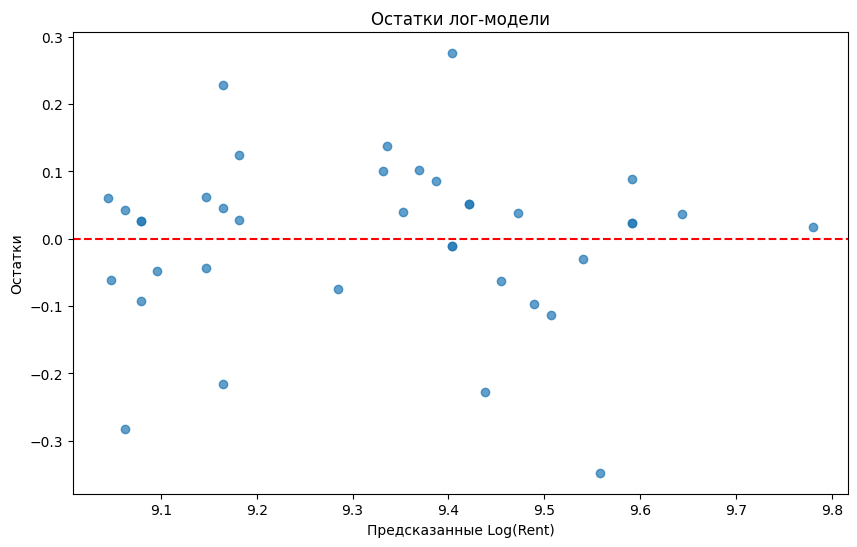

In [27]:
print("Устранение гетероскедастичности логарифмированием")
df['Log_Rent'] = np.log(df['Rent'])
y_log = df['Log_Rent']
model_log = sm.OLS(y_log, X_refined).fit()
print(model_log.summary())

residuals_log = model_log.resid
fitted_log = model_log.fittedvalues

plt.figure(figsize=(10, 6))
plt.scatter(fitted_log, residuals_log, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Предсказанные Log(Rent)')
plt.ylabel('Остатки')
plt.title('Остатки лог-модели')
plt.show()

In [ ]:
df_clean = df.copy()

def remove_outliers(X_tr, y_tr, columns, factor=1.5):
    mask = pd.Series(True, index=X_tr.index)
    for col in columns:
        Q1 = X_tr[col].quantile(0.25)
        Q3 = X_tr[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        mask &= (X_tr[col] >= lower) & (X_tr[col] <= upper)
    return X_tr[mask], y_tr[mask]

X = df_clean.drop(['Rent'], axis=1)
y = df_clean['Rent']

for col in df_clean.columns:
    if df_clean[col].dtype in [np.float64, np.int64]:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)
    else:
        df_clean[col].fillna(df_clean[col].mode()[0] if not df_clean[col].mode().empty else "Unknown", inplace=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_cols = ['Floor', 'Total_Floors', 'Area']
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

X_train, y_train = remove_outliers(X_train, y_train, numeric_cols)

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

# 6. Пайплайн с моделью
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# 7. Обучение
pipeline.fit(X_train, y_train)

# 8. Оценка
score = pipeline.score(X_test, y_test)
print(f'R^2 на тесте: {score:.3f}')

R^2 на тесте: 0.333


C:\Users\user\AppData\Local\Temp\ipykernel_28120\4041071663.py:21: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_clean[col].fillna(df_clean[col].mode()[0] if not df_clean[col].mode().empty else "Unknown", inplace=True)
C:\Users\user\AppData\Local\Temp\ipykernel_28120\4041071663.py:19: ChainedAssignmentError: A value is being set o